In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dataset
import sklearn.datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Classical ML models for comparison
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc,
    roc_auc_score
)

# Deep Learning
import tensorflow as tf
tf.random.set_seed(42)
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully!
TensorFlow version: 2.20.0


In [3]:
# Loading the data from sklearn
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

# Loading into a DataFrame
data_frame = pd.DataFrame(
    breast_cancer_dataset.data,
    columns=breast_cancer_dataset.feature_names
)

# Adding the target column
data_frame['label'] = breast_cancer_dataset.target

print('Dataset loaded successfully!')
print(f'Shape: {data_frame.shape}')
print(f'Features: {data_frame.shape[1] - 1}')
print(f'Samples: {data_frame.shape[0]}')

Dataset loaded successfully!
Shape: (569, 31)
Features: 30
Samples: 569


In [4]:
# First 5 rows
data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
# Last 5 rows
data_frame.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [6]:
# Dataset info
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
# Checking for missing values
print('Missing values in each column:')
print(data_frame.isnull().sum().sum())
print('No missing values!')

Missing values in each column:
0
No missing values!


In [8]:
# Statistical summary
data_frame.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [9]:
# Checking the distribution of Target Variable
print('Target Variable Distribution:')
print(data_frame['label'].value_counts())
print()
print('0 --> Malignant (Cancerous)')
print('1 --> Benign (Non-Cancerous)')

total = len(data_frame)
malignant = (data_frame['label'] == 0).sum()
benign = (data_frame['label'] == 1).sum()
print(f'\nMalignant: {malignant} ({malignant/total*100:.1f}%)')
print(f'Benign:    {benign} ({benign/total*100:.1f}%)')

Target Variable Distribution:
label
1    357
0    212
Name: count, dtype: int64

0 --> Malignant (Cancerous)
1 --> Benign (Non-Cancerous)

Malignant: 212 (37.3%)
Benign:    357 (62.7%)


In [10]:
# Group means by label (are features different between malignant and benign?)
print('Mean feature values grouped by diagnosis:')
data_frame.groupby('label').mean().T.head(10)

Mean feature values grouped by diagnosis:


label,0,1
mean radius,17.462830,12.146524
mean texture,21.604906,17.914762
mean perimeter,115.365377,78.075406
mean area,978.376415,462.790196
mean smoothness,0.102898,0.092478
mean compactness,0.145188,0.080085
mean concavity,0.160775,0.046058
mean concave points,0.087990,0.025717
mean symmetry,0.192909,0.174186
mean fractal dimension,0.062680,0.062867


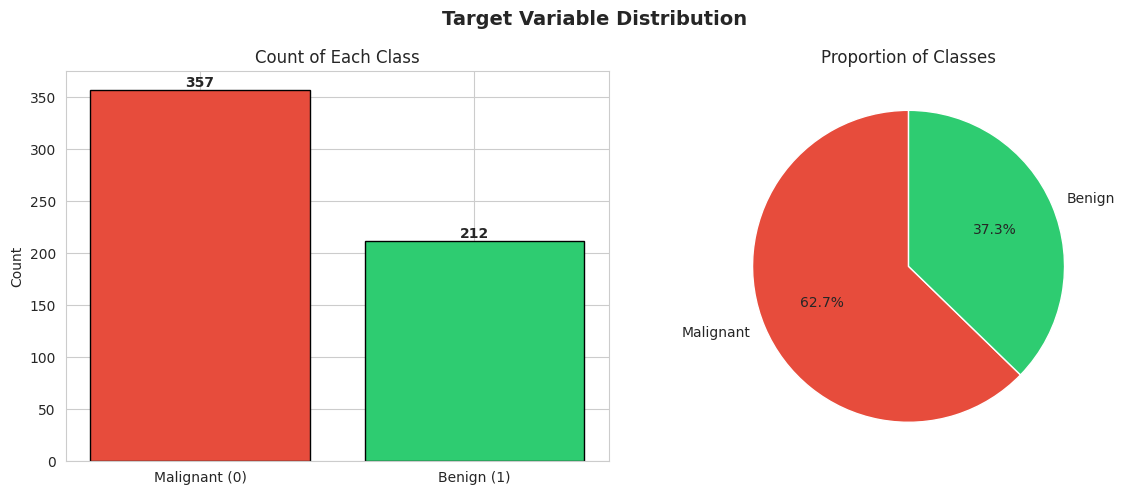

In [11]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')

# Count plot
colors = ['#e74c3c', '#2ecc71']
counts = data_frame['label'].value_counts()
axes[0].bar(['Malignant (0)', 'Benign (1)'], counts.values, color=colors, edgecolor='black')
axes[0].set_title('Count of Each Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Malignant', 'Benign'],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion of Classes')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

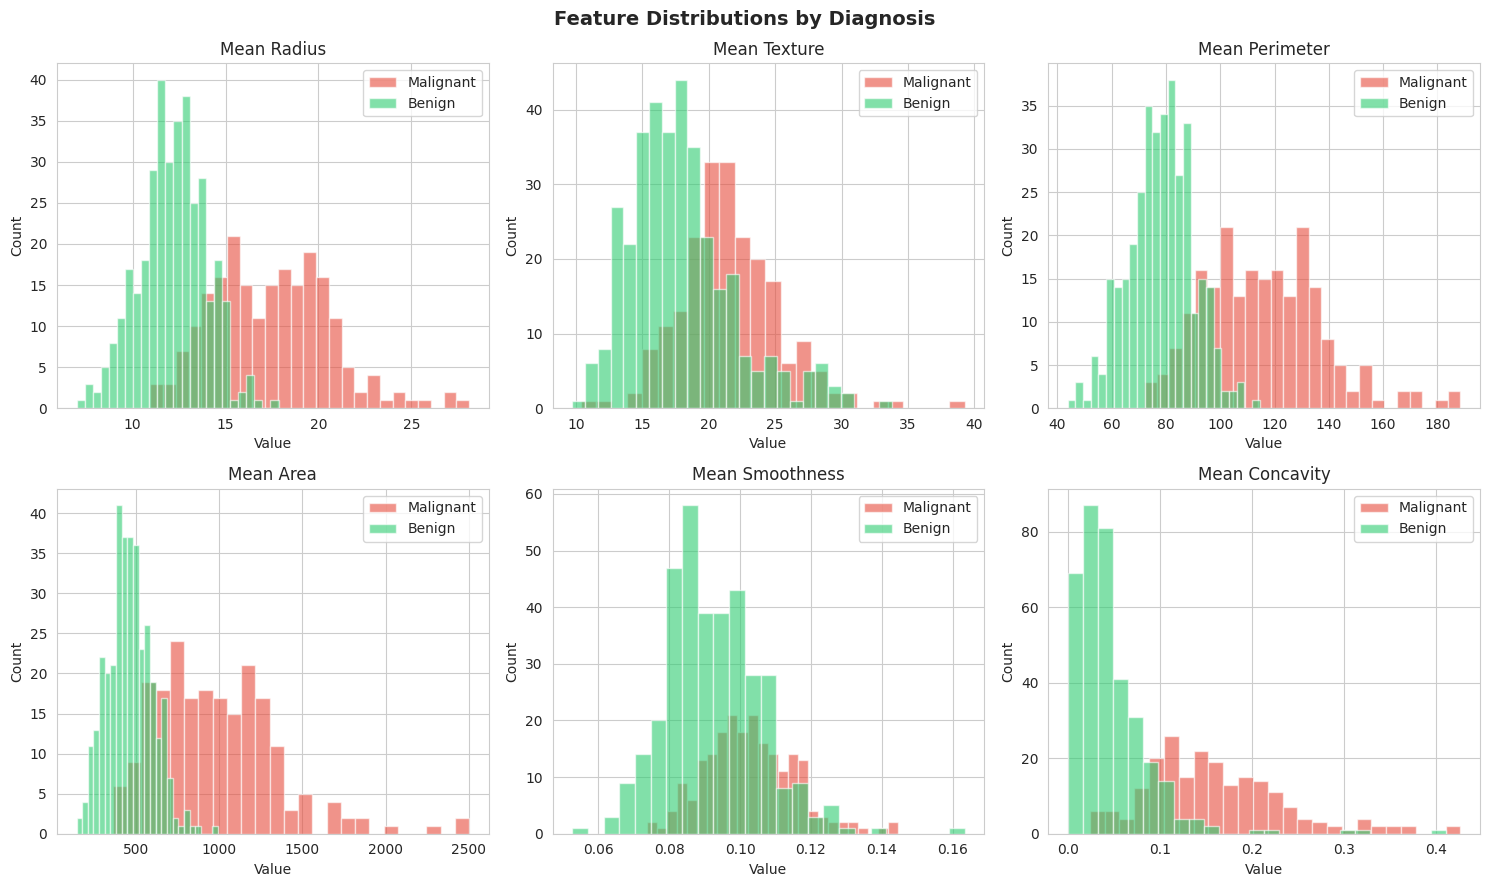

Notice how malignant tumors tend to have larger radius, perimeter, and area!


In [13]:
# Feature distributions: Top 6 most important features
top_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Feature Distributions by Diagnosis', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feature in enumerate(top_features):
    malignant_data = data_frame[data_frame['label'] == 0][feature]
    benign_data    = data_frame[data_frame['label'] == 1][feature]
    axes[i].hist(malignant_data, bins=25, alpha=0.6, color='#e74c3c', label='Malignant')
    axes[i].hist(benign_data,    bins=25, alpha=0.6, color='#2ecc71', label='Benign')
    axes[i].set_title(feature.title())
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Notice how malignant tumors tend to have larger radius, perimeter, and area!')

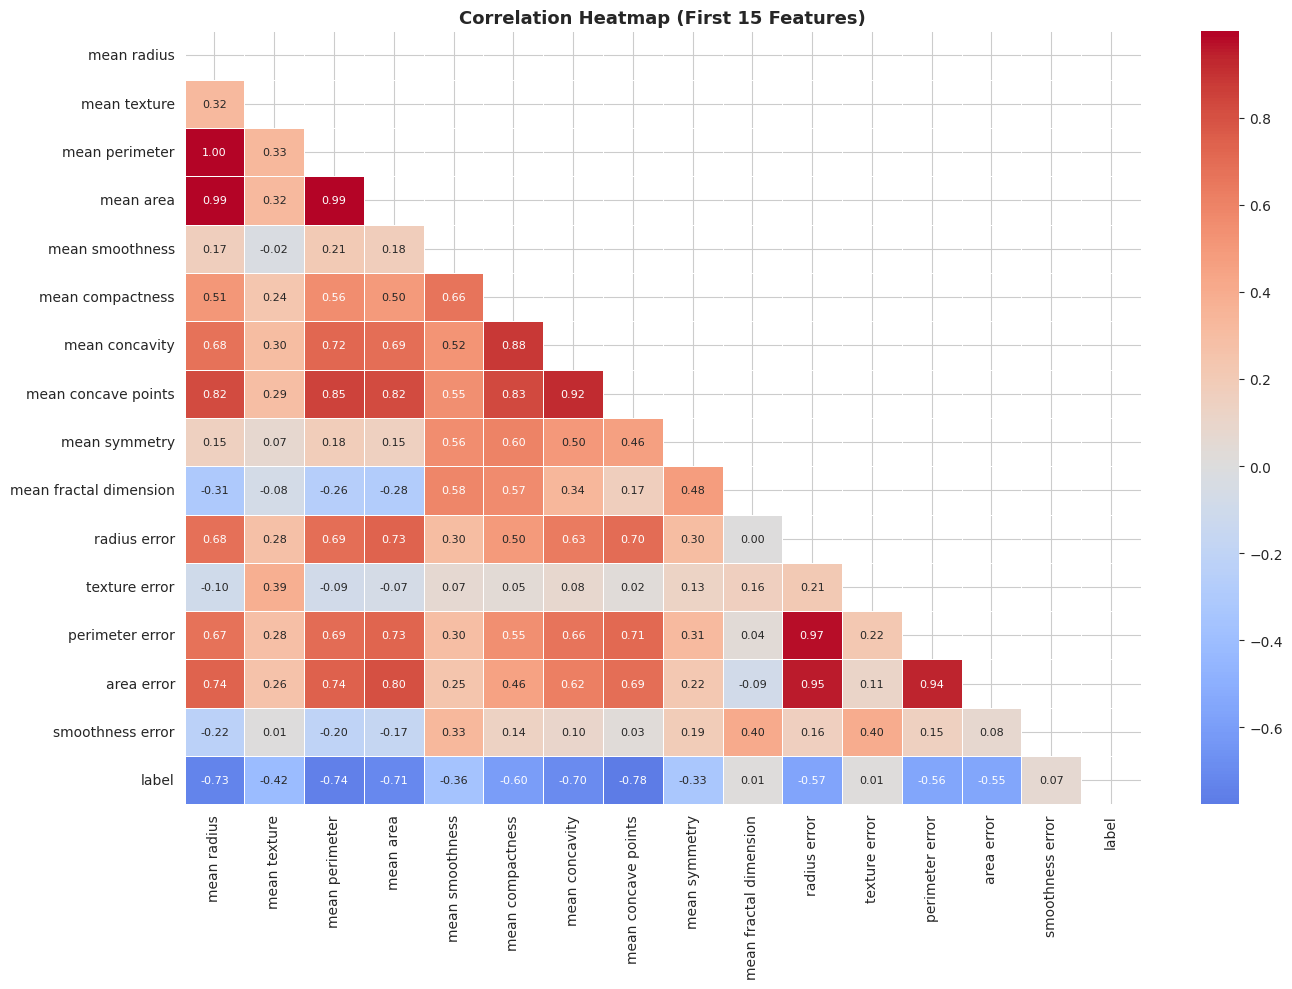

In [14]:
# Correlation Heatmap (first 15 features for readability)
plt.figure(figsize=(14, 10))
subset = data_frame[list(breast_cancer_dataset.feature_names[:15]) + ['label']]
corr = subset.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap (First 15 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Separating features and target
X = data_frame.drop(columns='label', axis=1)
Y = data_frame['label']

print('Features (X) shape:', X.shape)
print('Target (Y) shape:', Y.shape)

Features (X) shape: (569, 30)
Target (Y) shape: (569,)


In [16]:
# Splitting data into training (80%) and testing (20%)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')

Training set: 455 samples
Testing set:  114 samples


In [17]:
# Standardizing the data
# fit_transform on training data, only transform on test data
# (we must NOT fit the scaler on test data — that would be data leakage)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

print('Before standardization — mean of first feature:', round(X_train.iloc[:,0].mean(), 2))
print('After standardization  — mean of first feature:', round(X_train_std[:,0].mean(), 4))
print('\n Data standardized successfully!')

Before standardization — mean of first feature: 14.1
After standardization  — mean of first feature: -0.0

 Data standardized successfully!


In [18]:
# Building the improved Neural Network
model = keras.Sequential([
    layers.Input(shape=(30,)),

    # First hidden layer
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Second hidden layer
    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Third hidden layer
    layers.Dense(16, activation='relu'),

    # Output layer (binary classification)
    layers.Dense(1, activation='sigmoid')
])

# Compiling with multiple metrics
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 192 (768.00 B)

In [19]:
# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

# Training the Neural Network
history = model.fit(
    X_train_std, Y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f'\n Training complete! Stopped at epoch {len(history.history["loss"])}')

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.6968 - auc: 0.7102 - loss: 0.6887 - precision: 0.6971 - recall: 0.9186 - val_accuracy: 0.8261 - val_auc: 0.8677 - val_loss: 0.6238 - val_precision: 0.8235 - val_recall: 0.9333 - learning_rate: 0.0010
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8484 - auc: 0.9203 - loss: 0.4871 - precision: 0.8333 - recall: 0.9496 - val_accuracy: 0.9130 - val_auc: 0.9365 - val_loss: 0.5429 - val_precision: 0.8824 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9071 - auc: 0.9618 - loss: 0.3956 - precision: 0.9074 - recall: 0.9496 - val_accuracy: 0.9348 - val_auc: 0.9656 - val_loss: 0.4659 - val_precision: 0.9091 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9242 - auc: 0.9737 - loss: 0.3387 - precision: 0.9127 - recall: 0.9729 - val_accuracy: 0.9130 - val_auc: 0.9750 - val_loss: 0.4015 - val

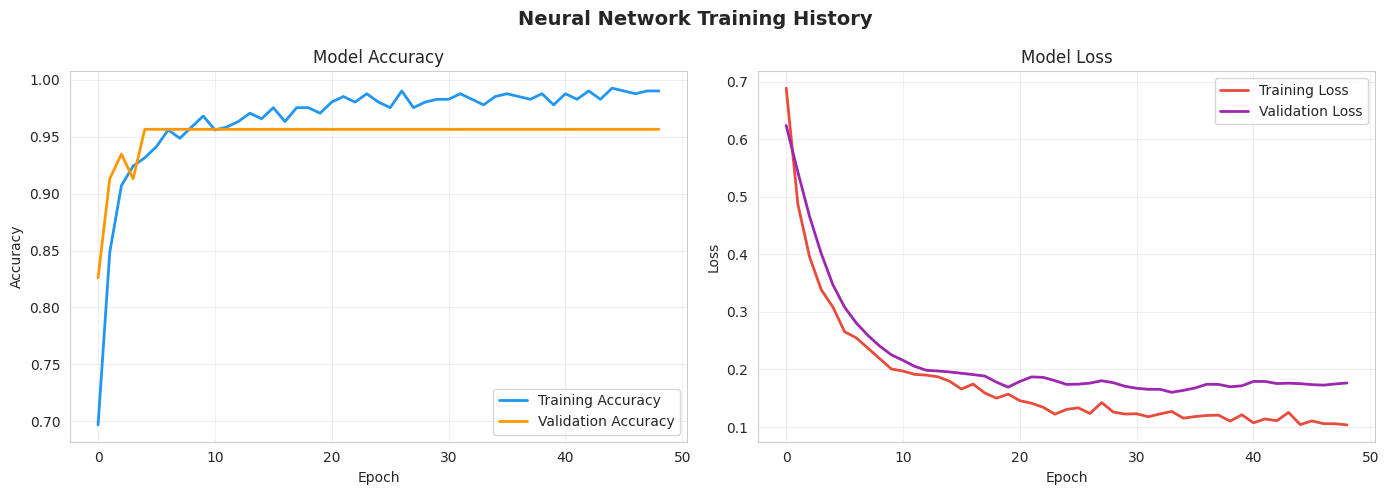

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Neural Network Training History', fontsize=14, fontweight='bold')

# Accuracy curves
axes[0].plot(history.history['accuracy'],    label='Training Accuracy',   color='#2196F3', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#FF9800', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Loss curves
axes[1].plot(history.history['loss'],     label='Training Loss',   color='#e74c3c', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#9C27B0', linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Evaluate on test data
print('='*50)
print('TEST SET EVALUATION')
print('='*50)
test_results = model.evaluate(X_test_std, Y_test, verbose=0)
metric_names = ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']
for name, val in zip(metric_names, test_results):
    print(f'{name:12}: {val:.4f}')

TEST SET EVALUATION
Loss        : 0.1509
Accuracy    : 0.9825
AUC         : 0.9940
Precision   : 0.9855
Recall      : 0.9855


In [22]:
# Generate predictions
Y_pred_prob = model.predict(X_test_std).flatten()
Y_pred      = (Y_pred_prob > 0.5).astype(int)

# Classification Report
print('='*55)
print('CLASSIFICATION REPORT')
print('='*55)
print(classification_report(Y_test, Y_pred,
                             target_names=['Malignant (0)', 'Benign (1)']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step
CLASSIFICATION REPORT
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        45
   Benign (1)       0.99      0.99      0.99        69

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



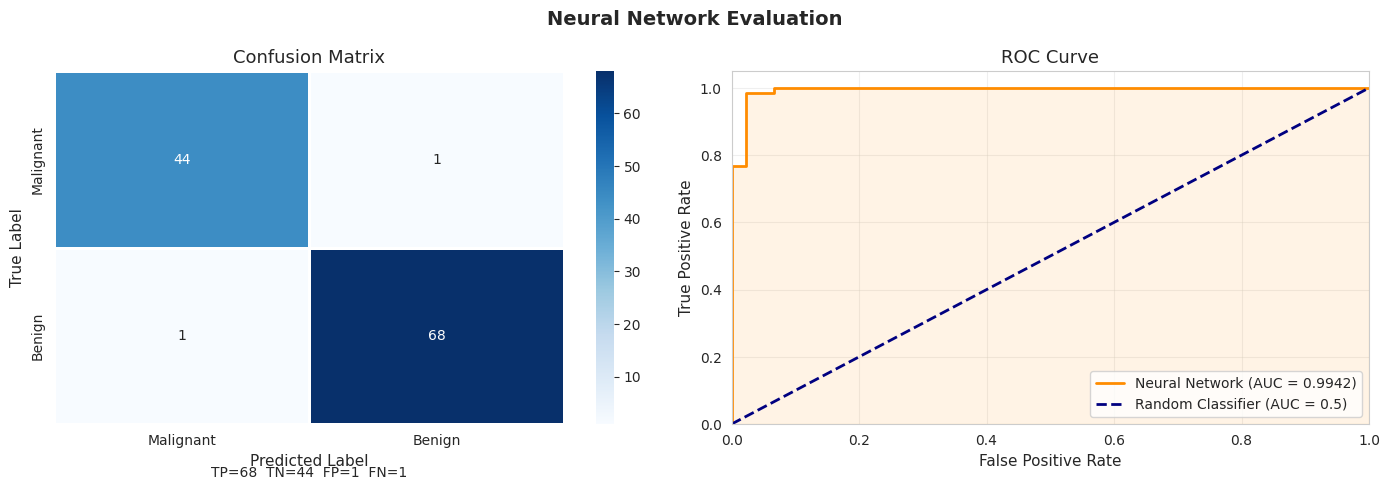


AUC-ROC Score: 0.9942 (closer to 1.0 = better)


In [23]:
# Confusion Matrix and ROC Curve — side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Neural Network Evaluation', fontsize=14, fontweight='bold')

# --- Confusion Matrix ---
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            linewidths=2, linecolor='white')
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Add annotations
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15,
    f'TP={tp}  TN={tn}  FP={fp}  FN={fn}',
    ha='center', transform=axes[0].transAxes, fontsize=10)

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(Y_test, Y_pred_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Neural Network (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2,
             linestyle='--', label='Random Classifier (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nAUC-ROC Score: {roc_auc:.4f} (closer to 1.0 = better)')

In [24]:
print('Training comparison models...\n')

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF)':           SVC(probability=True, kernel='rbf', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

comparison = {}

for name, clf in classifiers.items():
    clf.fit(X_train_std, Y_train)
    preds = clf.predict(X_test_std)
    probs = clf.predict_proba(X_test_std)[:, 1]
    comparison[name] = {
        'Accuracy':  round(accuracy_score(Y_test, preds) * 100, 2),
        'AUC-ROC':   round(roc_auc_score(Y_test, probs), 4)
    }
    print(f' {name} trained')

# Add Neural Network results
comparison['Neural Network (Ours)'] = {
    'Accuracy':  round(accuracy_score(Y_test, Y_pred) * 100, 2),
    'AUC-ROC':   round(roc_auc_score(Y_test, Y_pred_prob), 4)
}

comp_df = pd.DataFrame(comparison).T.sort_values('AUC-ROC', ascending=False)
print('\n' + '='*45)
print('MODEL COMPARISON RESULTS')
print('='*45)
print(comp_df.to_string())

Training comparison models...

 Logistic Regression trained
 SVM (RBF) trained
 Random Forest trained

MODEL COMPARISON RESULTS
                       Accuracy  AUC-ROC
Logistic Regression       97.37   0.9971
SVM (RBF)                 96.49   0.9971
Neural Network (Ours)     98.25   0.9942
Random Forest             93.86   0.9865


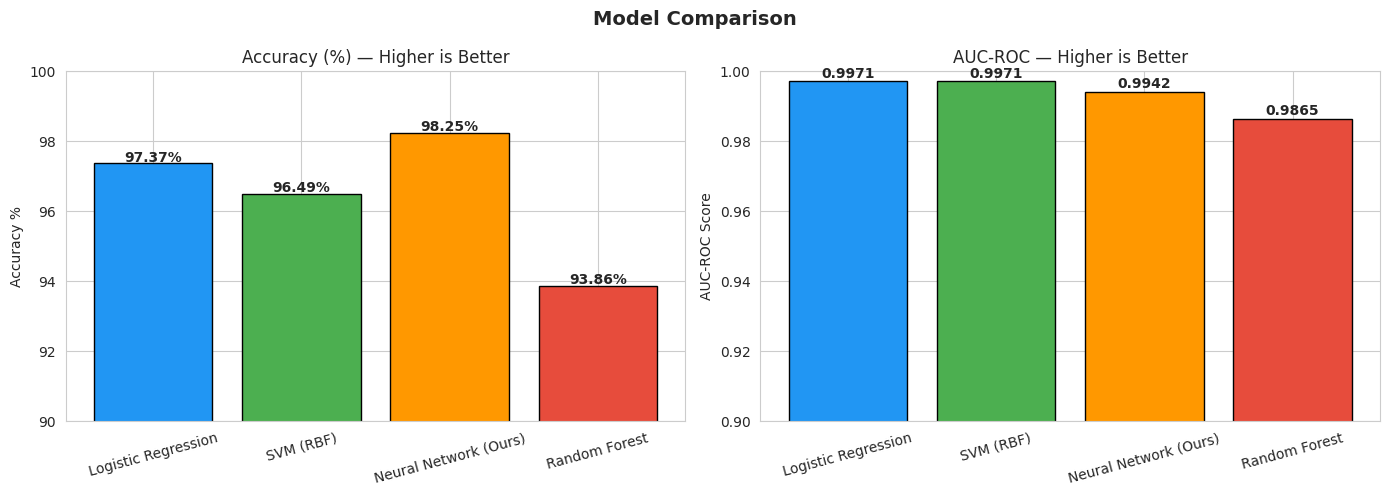

In [25]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF9800', '#e74c3c']
models_list = comp_df.index.tolist()

# Accuracy
bars1 = axes[0].bar(models_list, comp_df['Accuracy'], color=colors, edgecolor='black')
axes[0].set_title('Accuracy (%) — Higher is Better')
axes[0].set_ylabel('Accuracy %')
axes[0].set_ylim(90, 100)
axes[0].tick_params(axis='x', rotation=15)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{bar.get_height():.2f}%', ha='center', fontweight='bold')

# AUC-ROC
bars2 = axes[1].bar(models_list, comp_df['AUC-ROC'], color=colors, edgecolor='black')
axes[1].set_title('AUC-ROC — Higher is Better')
axes[1].set_ylabel('AUC-ROC Score')
axes[1].set_ylim(0.9, 1.0)
axes[1].tick_params(axis='x', rotation=15)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
def predict_cancer(input_data):
    """
    Predicts whether a breast tumor is Malignant or Benign.

    Parameters:
        input_data: tuple of 30 feature values from biopsy measurements

    Returns:
        Prediction result with confidence score
    """
    input_array    = np.asarray(input_data).reshape(1, -1)
    input_std      = scaler.transform(input_array)
    prediction_prob = model.predict(input_std, verbose=0)[0][0]
    prediction_label = int(prediction_prob > 0.5)
    confidence = prediction_prob if prediction_label == 1 else (1 - prediction_prob)

    print('='*50)
    print('     BREAST CANCER PREDICTION RESULT')
    print('='*50)
    print(f'  Confidence Score: {confidence*100:.2f}%')

    if prediction_label == 0:
        print('  Diagnosis: 🔴 MALIGNANT (Cancerous)')
        print('  Recommendation: Immediate medical attention advised.')
    else:
        print('  Diagnosis: 🟢 BENIGN (Non-Cancerous)')
        print('  Recommendation: Regular monitoring advised.')

    print('='*50)
    print('   This is a screening tool only.')
    print('   Always consult a qualified physician.')
    print('='*50)
    return prediction_label


# Example 1: Malignant case (from dataset)
print('--- Test Case 1 (Expected: Malignant) ---')
malignant_sample = (17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,
                    0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,
                    0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,
                    0.1622,0.6656,0.7119,0.2654,0.4601,0.1189)
predict_cancer(malignant_sample)

# Example 2: Benign case (from dataset)
print('--- Test Case 2 (Expected: Benign) ---')
benign_sample = (11.76,21.6,74.72,427.9,0.08637,0.04966,0.01657,0.01115,
                 0.1495,0.05888,0.4062,1.21,2.635,28.47,0.005857,0.009758,
                 0.01168,0.007445,0.02406,0.001769,12.98,25.72,82.98,516.5,
                 0.1085,0.08615,0.05523,0.03715,0.2433,0.06563)
predict_cancer(benign_sample)

--- Test Case 1 (Expected: Malignant) ---
     BREAST CANCER PREDICTION RESULT
  Confidence Score: 99.73%
  Diagnosis: 🔴 MALIGNANT (Cancerous)
  Recommendation: Immediate medical attention advised.
   This is a screening tool only.
   Always consult a qualified physician.
--- Test Case 2 (Expected: Benign) ---
     BREAST CANCER PREDICTION RESULT
  Confidence Score: 99.05%
  Diagnosis: 🟢 BENIGN (Non-Cancerous)
  Recommendation: Regular monitoring advised.
   This is a screening tool only.
   Always consult a qualified physician.


1

In [31]:
import pickle

# Save the Neural Network model
model.save('breast_cancer_nn_model.h5')
print('Neural Network model saved as breast_cancer_nn_model.h5')

# Save the scaler (important — must use same scaler at prediction time)
with open('breast_cancer_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved as breast_cancer_scaler.pkl')

print('\nTo load and use later:')
print('  model  = keras.models.load_model("breast_cancer_nn_model.h5")')
print('  scaler = pickle.load(open("breast_cancer_scaler.pkl", "rb"))')

Neural Network model saved as breast_cancer_nn_model.h5
Scaler saved as breast_cancer_scaler.pkl

To load and use later:
  model  = keras.models.load_model("breast_cancer_nn_model.h5")
  scaler = pickle.load(open("breast_cancer_scaler.pkl", "rb"))
